# SVM Exercises

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn import metrics

Load Pima diabetes dataset

In [3]:
url = "https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week1/diabetes.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

# YOUR CODE HERE

df = pd.read_csv(url, names=names)
df.head()

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Split data into training, colidation, and test sets with a test size of 25%

In [7]:
# YOUR CODE HERE

X = df.drop('class', axis=1)
y = df['class']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

Create a model with sklearn's SVC and a high gamma value (perhaps 1.0)

In [8]:
# YOUR CODE HERE

from sklearn.svm import SVC

clf = SVC(gamma=1.0)
clf.fit(X_train, y_train)

SVC(gamma=1.0)

Print accuracy of training and validation data

In [9]:
# YOUR CODE HERE

print('Training accuracy: ', clf.score(X_train, y_train))
print('Validation accuracy: ', clf.score(X_val, y_val))

Training accuracy:  1.0
Validation accuracy:  0.6805555555555556


Create a model with sklearn's SVC and a low gamma value (perhaps .001)

In [12]:
# YOUR CODE HERE

clf2 = SVC(gamma = 0.01)

clf2.fit(X_train, y_train)

SVC(gamma=0.01)

Print accuracy of training and validation data

In [13]:
# YOUR CODE HERE

print('Training accuracy: ', clf2.score(X_train, y_train))
print('Validation accuracy: ', clf2.score(X_val, y_val))

Training accuracy:  0.9791666666666666
Validation accuracy:  0.6875


Explain the accuracy results below.

Despite the model's training accuracy lowering from 1 to 0.9791667, the model overfitted less as the validation accuracy improved, which is good. Additionally, based on the analysis below, the low gamma model actually caught some true positives compared to the high gamma model which predicted negative for every single patient.

Print the confusion matrices for your high and low gamma models (both numeric and visualized)

In [16]:
# YOUR CODE HERE

y_pred = clf.predict(X_val)
y_pred2 = clf2.predict(X_val)

print(metrics.confusion_matrix(y_val, y_pred))
print(metrics.confusion_matrix(y_val, y_pred2))

[[98  0]
 [46  0]]
[[95  3]
 [42  4]]


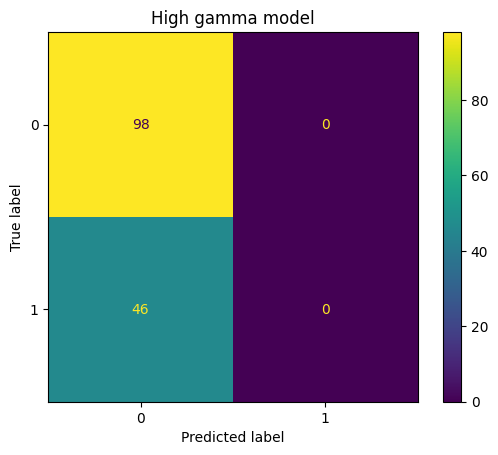

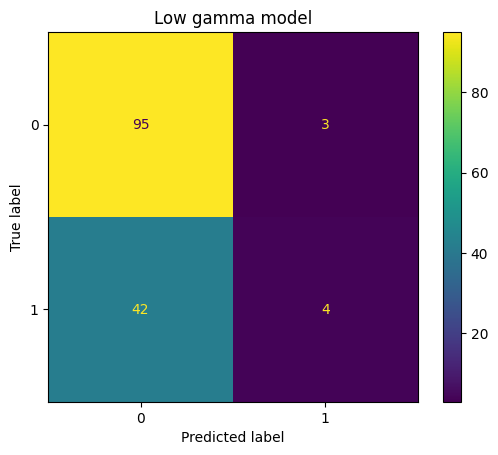

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_val, y_pred)
plt.title('High gamma model'); plt.show()

ConfusionMatrixDisplay.from_predictions(y_val, y_pred2)
plt.title('Low gamma model'); plt.show()